<img src="../figures/logos/logo_usc.jpg" align=right width='80px'/>
<br>


<table width="100%">
<td style="font-size:40px;font-style:italic;text-align:left;background-color:rgba(0, 220, 170,0.7)">
Elementary Quantum Circuitry
</td></table>


$ \renewcommand{\bra}[1]{\langle #1|} $
$ \renewcommand{\ket}[1]{|#1\rangle} $
$ \renewcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \renewcommand{\i}{{\color{blue} i}} $ 
$ \newcommand{\Hil}{{\mathbb H}} $
$ \newcommand{\cg}[1]{{\rm C}#1} $

In [2]:
import sys
sys.path.append('../')
import macro_tQ as tQ

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import array_to_latex

<a id='top'></a>

- [Equivalent Circuits](#equiv)

    - [Conjugation](#conjugation) 
    - [Controlled Circuits](#controlled)
    - [Deferred Measurements](#deferred)
    

<br>

- [Usefull quantum routines](#routines)
    - [Phase kickback](#kickback)
    - [Reset circuit](#reset)
    - [Clifford circuits](#clifford)

<br>


- [Universal quantum computing](#universal)

    - [Decomposition theorem](#decomp)
    
    - [Approximatio theorem](#approx)

<br>

- [Quality measures in quantum circuits](#quality)

<br>

- [Computational complexity](#complexity)

    - [Classical complexity](#classcomp)
    
    - [Quantum complexity](#quantcomp)


<a id='equiv'></a>

# Equivalent Circuits


Operators can be combined together to produce new operators. The associated circuits are called *equivalent circuits*.

The possibility of factorizing unitaries into simple ones is an essential ingredient of the paradigm of quantum computation by gates. Each hardware is especially taylored to perform with high performance a basic set of "native" gates.



<a id='conjugation'></a>

## Conjugation


A very common case is the **conjugation** of a gate $V$ by a **unitary** $U$


$$
V' = U V  U^\dagger  
$$

The conjugated operator $V'$ has **the same action** on the *rotated basis* $\{\ket{e'} = U\ket{e}\}$
as $V$ has on the original $\{\ket{e}\}$.

 Therefore, 
 - the *eigenvalues* of $V$ and $V'$ are the *same* and 
 
 - the *eigenvectors* are the *rotated*

$$
\lambda' = \lambda ~~~~~~\hbox{and}~~~~~~  \ket{\lambda}' = U\ket{\lambda}
$$

Let's check it

\begin{eqnarray}
\fbox{$V \ket{\lambda}= \lambda\ket{\lambda}$} ~~& \Rightarrow & ~~~V'\ket{\lambda}' = (UVU^\dagger) U\ket{\lambda} = UV\ket{\lambda} =  U(\lambda\ket{\lambda}) = \lambda U\ket{\lambda} = \lambda\ket{\lambda}' \\ \rule{0mm}{7mm}
&~~\Rightarrow & ~~~ \fbox{$ V' \ket{\lambda}' = \lambda\ket{\lambda}'$}
\end{eqnarray}
<br>

For example 


<figure><center>
<a id='fig_ref'></a>
<img src="images/H_conjugation.png" align=center width='50%'/>
<center></center>
</center></figure>
<br>

and, equivalently, exchanging $X \leftrightarrow Z$. 


<br>

- This type of equivalence follows from the algebraic identities
<br>
<br>
\begin{eqnarray}
HXH = Z ~~~~~&&~~ ~~~
HZH = X \nonumber
\end{eqnarray}
<br>
which are easy to visualize by remembering that $H$ is a 180$^\circ$ rotation around the diagonal axis in the $XZ$ plane


<br>

- Analogously
<br>
<br>
\begin{eqnarray}
S X S^\dagger  = Y~~~~~&&~~~ ~~~
S Y S^\dagger = -X  ~~~~~~~~ S Z S^\dagger = Z\nonumber\\
\end{eqnarray}
<br>
are also easy to visualize by remembering that 
 $S=\sqrt{Z}$ is a $90^\circ$ rotation around the $Z$ axis.


### Conjugation of an Exponential

many unitary gates are of the form $V = e^{\alpha A}$

For example, if $A = \hat{\bf n}\cdot \boldsymbol{\sigma} $ then $  ~\Rightarrow ~V= R_{\hat{\bf n}}(\theta)$ is the operator that rotates an angle $\theta$ around the vector $\hat{\bf n}$ on the Bloch sphere.

$$
 R_{\hat{\bf n}}(\theta) = e^{-i\frac{\theta}{2}\hat{\bf n}\cdot \boldsymbol{\sigma}}
$$



<div class="alert alert-block alert-info">
<p style="color: navy;">
<b>Lemma:</b> the conjugation of an exponential is exponentiated
<br>
</div>

\begin{eqnarray}
U e^{\alpha A} U^\dagger &=&  U \left(1 + \alpha A  + \frac{1}{2} \alpha^2 A^2 + ... \right) U^\dagger \\ \rule{0mm}{8mm}
&=& 1 + \alpha UAU^\dagger + \frac{1}{2}\alpha^2 UAU^\dagger U AU^\dagger + ... \\ \rule{0mm}{8mm}
&=& e^{ \alpha UAU^\dagger} 
\end{eqnarray}


For the case $A = \hat{\bf n}\cdot \boldsymbol{\sigma} $ the conjugation is
<br><br>
$$
U A U^\dagger ~\to ~U (\hat{\bf n}\cdot \boldsymbol{\sigma} ) U^\dagger = \hat{\bf n}'\cdot  \boldsymbol{\sigma} = A'
$$
<br>
where $\hat{\bf n}' = U \hat{\bf n}$.

<div class="alert alert-block alert-info">
<p style="color: navy;">
<b>Corollary:</b>
  $~$ <i>the conjugation of a rotation around an axis produces a rotation around the conjugated axis</i>
<br><br>
$$
U R_{\hat{\bf n}}(\theta) U^\dagger = R_{U\hat{\bf n}}(\theta)
$$
</div>


For example:

\begin{eqnarray}
H R_z(\theta) H &=& e^{-i \theta/2 HZH} =  e^{-i (\theta/2) X}. \\ \rule{0mm}{8mm}
&=& R_x(\theta)
\end{eqnarray}

<br>
<figure><center>
<a id='fig_ref'></a>
<img src="images/HRzHconjugation.png" align=center width='70%'/>
<center></center>
</center></figure>
<br>


<a id='controlled'></a>

## Controlled circuits

The controlled gate $\cg{Z} =  {\rm diag}(1,1,1,-1)$ is symmetric since all it does is change the sign of the state $\ket{11}$. That is,

<br>

<figure><center>
<img src="images/Equiv_Z.png" align=center width='30%'/>
<center></center>
</center></figure>

<br>

In fact, $\cg{Z}$ is a particular case of $\cg{P(\phi)} = {\rm diag} (1,1,1, e^{i\phi})$, for which the equivalence is the same.


Another important equivalence is

<br>
<figure><center>
<img src="images/Equiv_HH.png" align=center width='600px'/>
<center></center>
</center></figure>
<br>

To prove this identity, observe that the three gates of the second qubit can be composed to give $HXH=Z$. On the other hand, the two Hadamard gates on the first qubit cannot be multiplied due to a control between them. 
However, using the previous equivalence, we can invert the $\cg{Z}$ gate and, finally, conjugate back the first qubit to find $HZH=X$.


Another non-intuitive but very important equivalence relates three CNOT operations with the permutation U$_{\rm SWAP}$


<br>
<figure><center>
<img src="images/Equiv_CNOTs.png" align=center width='600px'/>
<center></center>
</center></figure>
<br>

There is no simple way to prove this identity, so it is advisable to write the matrices associated with each member and verify that they are equal.

This identity is so important that, in fact, it is the way the U$_{\rm SWAP}$ operator is implemented in a quantum computer.

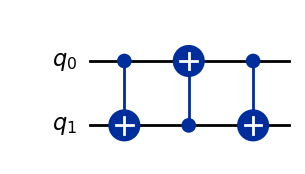

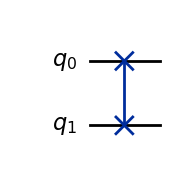

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [29]:
from qiskit import QuantumCircuit
from qiskit_aer import UnitarySimulator

U_simulator = UnitarySimulator

qc_left= QuantumCircuit(2)
qc_right= QuantumCircuit(2)

qc_left.cx(0,1)
qc_left.cx(1,0)
qc_left.cx(0,1)
qc_right.swap(1,0)
 
display(qc_left.draw(output='mpl'))    
display(qc_right.draw(output='mpl'))    


from qiskit.quantum_info import Operator

display(Operator.from_circuit(qc_left).draw('latex') )
display(Operator.from_circuit(qc_right).draw('latex'))



The globally controlled phase gate, $\cg{K_\phi} = {\rm diag} (1,1,e^{i\phi}, e^{i\phi})$, secretly, is not a controlled gate


<br>
<figure><center>
<img src="images/Equiv_Kphase.png" align=center width='30%'/>
<center></center>
</center></figure>
<br>

Care must be taken when passing Pauli operators over a control.
It is easy to verify that the result of the following two circuits is the same, therefore they are equivalent.

<br>
<figure><center>
<img src="images/control_conj_Z.png" align=center width='40%'/>
<center></center>
</center></figure>
<br>

On the other hand, conjugation by $X$ or by $Y$ changes the control qubit from $\ket{1}$ to $\ket{0}$, which is represented with an empty button.





<br>
<figure><center>
<img src="images/control_conj_XY.png" align=center width='70%'/>
<center></center>
</center></figure>
<br>






We can verify the truth of the previous identities by programming the circuits of both members




<a id='deferred'></a>

## Deferred measurements 

In many instances, the result of a measurement is used to perform a conditional operation on a certain qubit. This is the case in teleportation or superdense coding.

In these cases, there is an important circuit equivalence that obeys following principle

<div class="alert alert-block alert-info">
<p style="text-align: center;"> <p style="text-align: left ;color: navy;">  
<b>Theorem:</b> <i>Deferred Measurement Principle</i>
<br>    
Measurements can always be moved from an intermediate place in a circuit to the end of it. If the results of the measurements are used for classically controlled operations, these can be replaced by quantumly conditioned operators 
<br>
<br>     
</p></div>

The following image illustrates the circuit equivalence referred to by the previous theorem.

<br>
<figure><center>
<img src="images/deferred_meas.png" align=center width='70%'/>
<center></center>
</center></figure>
<br>

The third figure is just notation in which a measurement device directly controls an operator.

<div class="alert alert-block alert-success">
<b>Exercise:</b> 
<br> demonstrate the equivalence of the previous circuits.  
</div>    



<a id='routines'></a>

# Useful routines 

[<<<](#top)



<a id='kickback'></a>

## Phase kickback



To see this, let us suppose that the controled qubit, that is the one on which the operator $U$ acts, is one of its eigenstates  (remember that the eigenvalues of a unitary operator are pure phases)

$$
U\ket{u} = e^{i\lambda} \ket{u}
$$

If a superposition $(a\ket{0}+b\ket{1})$ circulates through the *control qubit* and an eigenstate $\ket{u}$ of $U$ through the controlled qubit. The action of $\cg{U}$ is
<br>
<br>

$$
\cg{U}: (a\ket{0} + b\ket{1})\otimes \ket{u} ~\to ~   a\ket{0} I \ket{u} + b \ket{1}U\ket{u}  = a\ket{0}\ket{u} + b \ket{1}e^{i\lambda}\ket{u}  = \left( a\ket{0}\ket{u} + be^{i\lambda} \ket{1} \rule{0mm}{4mm} \right)\otimes \ket{u}
$$
<br>

The final result is that 

- the phase $e^{i\lambda}$ *has modified* the control state! 

- the  controlled qubit *has not changed*! 


The key is that, in the second step, the phase generated by the action of U *does not really belong* to either of the two spaces but to the product

So it can be ascribed to the first space, as we did in the last step

Hence the name *phase kickback*


The following circuit summarizes the phase kickback action
<br>
<br>

<figure><center>
<a id='fig_ref'></a>
<img src="images/phase_kickback.png" align=center width='35%'/>
<center></center>
</center></figure>


A very common case occurs when $U = X$, that is $\cg{U} = \hbox{CNOT}$. The eigenvalues of $X$ are those that form the basis $\ket{\pm}$. In the case of $\ket{-}$, we have that the phase is $e^{i\pi} = -1$
<br>
<br>

$$
X \ket{+} =  \ket{+}~~ ~,~~~~ X \ket{-} = - \ket{-} \, 
$$
<br>

Now with $x = 0,1$, the action of $\cg{X}$ gives 
<br>

$$
\cg{X} \big( \ket{x}\otimes \ket{-}\big) ~=~ \ket{x} X^x\ket{-} =  (-1)^x \ket{x} \otimes \ket{-}
$$

<br>

The phase kickback thus manages to *imprint* the value $x=0,1$ of the control qubit into a phase $(-1)^x = e^{i\pi x}$. 

<a id='reset'></a>
## Reset circuit

Intermediate measurements are used to perform operations controlled by a classical bit. We will see a use of this resource when we study teleportation. Here we will see how we can use this measurement to reset a qubit to the starting state $\ket{0}$.

In the following circuit, $\ket{\psi} = a\ket{0} + b\ket{1}$ can collapse in the measurement device to $\ket{0}$ or to 
$\ket{1}$. In both cases, the output of the circuit will be the state $\ket{0}$

<br>
<figure><center>
<img src="images/reset.png" align=center width='30%'/>
<center></center>
</center></figure>
<br>

<a id='clifford'></a>

## Clifford circuits



<div class="alert alert-block alert-info">
<p style="text-align: center;"> <p style="text-align: left ;color: navy;">  
<b>Definition:</b> a <i>Clifford operator</i>, $U$, is defined as one that <i>conjugates</i> a Pauli operator to another Pauli operator.
</p></div>

The Pauli operators themselves are Clifford operators. The corresponding conjugation simply reflects the Pauli operator. For example, with $U=Z$

$$
ZXZ = -X~~~~~~~~~ZYZ = -Y ~~~~~~~~~ZZZ = Z 
$$

But we also see that $H$ and $S$ are Clifford operators. 
In contrast, $T$ is not a Clifford operator.

<div class="alert alert-block alert-danger">
<b>Note:</b> 
    
The easiest way to calculate these conjugations is to remember the algebra of Pauli operators

$$
X Y = i Z ~~~~~ Y Z = i X ~~~~~ ZX = iY
$$
where all involve $X,Y$ and $Z$ in cyclic order.
Also, the fact that two different Pauli operators anti-commute. For example

$$
\{X,Y\} = XY + YX = 0
$$
</p></div>


This definition extends to multi-qubit gates. A *multi-qubit Clifford operator* is one that conjugates a Pauli string to give another Pauli string. For example

\begin{eqnarray}
(XXH) \, (YZX) \,  (XXH)^\dagger &=& XXH \otimes YZX \otimes XXH \\ \rule{0mm}{10mm}
&=& XYX \otimes  XZX \otimes HXH \\ \rule{0mm}{10mm}
&=& (-Y)\otimes (-Z) \otimes Z \\ \rule{0mm}{10mm} &=& YZZ
\end{eqnarray}

We can also conjugate operators obtained by exponentiation

$$
(XXH) \, e^{aYZX} \,  (XXH)^\dagger =e^{a XXH \otimes XZX \otimes XXH} =  e^{a YZZ}
$$

For 2 qubits, the *Clifford class* includes **controlled gates**

$$
\cg{X} \, (I\otimes X)\,  \cg{X} = X \otimes X
$$

which copies the operator $X$ onto the other qubit

This identity can be demonstrated graphically 

<br>
<figure><center>
<a id='fig_ref'></a>
<img src="images/clone_X.png" align=center width='90%'/>
<center></center>
</center></figure>
<br>


<a id='universal'></a>
   
# Universal Quantum Computing
[<<<](#top)

The goal of a *universal quantum computer* is to be able to implement the most general unitary operator

$$
U  = \sum_x \ket{f(x)}\bra{x}
$$

But each hardware is capable of implementing a limited set of simple gates. 


<a id='decomp'></a>

## Decomposition theorem

<div class="alert alert-block alert-info">
<p style="text-align: center;"> <p style="text-align: left ;color: navy;">  
<b>Theorem</b> <i>(Barenco et. al. 1995):</i> 
<br>
any unitary operator $U_n$ on $n$ qubits can be expressed as the product of 
<br>
<br>   
-  continuous <i>single-qubit</i> gates 
<br>  
<br>
-  CNOT gates.
</p></div>

For example, the controlled gate $\cg{P_\phi}$ allows the following decomposition
<br>
<figure><center>
<a id='fig_ref'></a>
<img src="images/Equiv_Phase.png" align=center width='60%'/>
<center></center>
</center></figure>
<br>

The proof of Barenco's theorem consists of several steps

1. Any operator $U_n$ on $n$ qubits can be decomposed as a *product of operators* $\cg{^kU}$ where $U$ is a 1-qubit operator controlled by $k$ qubits with $k=0,1,...,n-1$.

2. the operators $\hbox{C}^kU$ can be decomposed as products of an operator $\cg{U}$ and Toffoli CCNOT gates

In general for $\cg{^kU}$ we need $k-1$ ancillas


<br>
<figure><center>
<a id='fig_ref'></a>
<img src="images/CkUdecomposition.png" align=center width='40%'/>
<center></center>
</center></figure>
<br>


<a id="Toffolidecomposition"></a>
3. Toffoli gates can be decomposed as products of $H$, $\cg{X}$, and $\cg{S}$


<br>
<figure><center>
<a id='fig_ref'></a>
<img src="images/Toffolidecomposition.png" align=center width='50%'/>
<center></center>
</center></figure>
<br>


This is nothing more than the particular case of the general decomposition of $\cg{^2U}$ using 

$$U = X = HZH=HSSH =  (HSH)(HSH)= V^2 ~~\Rightarrow ~~V = HSH$$

<a id="CUdecomposition"></a>
4. A gate $\cg{U}$ can be uniquely decomposed using three rotations $A, B$, and $C$ that satisfy

$$
ABC = I ~~~~~,~~~~ e^{i\delta}  AXBXC = U
$$

<br>
<figure><center>
<a id='fig_ref'></a>
<img src="images/CUdecomposition.png" align=center width='60%'/>
<center></center>
</center></figure>
<br>

Indeed, if the control qubit is $\ket{0}$, the phase $P(\delta)$ does not affect it, and the effective operator on the second qubit is $ABC= I$.

On the other hand, if the first qubit is $\ket{1}$, then $AXBXC$ is applied to the second qubit, and the operator $P(\delta)$ adds the global phase, which being global, we can pass to the second qubit, making $e^{i\delta} AXBXC = U$

<details>
<summary><p style="text-align: right ;color: navy"> >> Demostración </p></summary>

The two algebraic conditions admit a unique solution for a generic unitary operator

$$
U = e^{i\delta}\begin{bmatrix}\displaystyle e^{-i(\alpha+\beta)/2}\cos\frac{\theta}{2} & \displaystyle - e^{i(-\alpha+\beta)/2}\sin\frac{\theta}{2}  \\  
\rule{0mm}{5mm}
\displaystyle   e^{i(\alpha-\beta)/2}\sin\frac{\theta}{2}  &\displaystyle e^{i(\alpha+\beta)/2}\cos\frac{\theta}{2}
\end{bmatrix} = e^{i\delta} AXBXC ~  \Longrightarrow ~
\left\{ \begin{array}{l} A = R_z(\alpha) R_y\left(\frac{\theta}{2}\right) \\ B = R_y\left(-\frac{\theta}{2}\right) R_z\left(-\frac{\alpha + \beta}{2}\right) \\
C = R_z\left( \frac{\beta-\alpha}{2}\right)\end{array}
\right.
$$

<i> Note: </i>: $U\in U(2)$ is a unitary operator and its determinant is a phase $\det U = e^{i\delta}$. On the other hand, $\det(AXBXC) = 1$, and therefore it is an element of $SU(2)$. For this reason, it is necessary to add the phase $e^{i\delta}$ to obtain a general unitary operator.
    
</details>    

<a id='aproxth'></a>

## Aproximation theorem



- Barenco's theorem decomposition is an exact identity capable of decomposing an infinite and continuous set of operators $U_n$ into CNOT gates and *continuous* $U$ gates 




- Quantum computing *fault tolerant* demands the **discretization** of the computing process.


- There is a *discrete set of universal gates* that can be programmed in a fault-tolerant manner 





 It may be different depending on the platform used. 

- In superconducting circuits 

\begin{eqnarray}
\hbox{Shor basis}~~
 ~&:& ~~ \{ H, T, \hbox{CNOT}\}  \nonumber \\ \rule{0mm}{5mm}
\hbox{NCT}~ ~&:& ~~ \{ X,\hbox{CNOT}, \hbox{Toffoli}\}   \nonumber
\end{eqnarray}


- It is important to relate universal gates with *native gates*

For example, in trapped ion computers there are the following 

$$
\{ \hbox{GPi},\hbox{Virtual}Z, \hbox{MS}\} 
$$

<br>
<br>
where 
$$
\hbox{GPi} = \begin{bmatrix} 0 & e^{-i\phi} \\e^{i\phi} & 0 \end{bmatrix}~~~,~~~
\hbox{Virtual}Z = \begin{bmatrix} e^{-i\phi} & 0 \\ 0 & e^{i\phi} \end{bmatrix} ~~,~~~~
$$

and the Mølmer-Sørensen gate

$$
\hbox{MS}(\phi_1,\phi_2) = \frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 0 & 0 & e^{-i(\phi_1+\phi_2)} \\ 0 & 1 &-i e^{-i(\phi_1-\phi_2)} & 0 \\ 0 & -i e^{i(\phi_1-\phi_2)} & 1 & 0  \\ 
-ie^{i(\phi_1+\phi_2)} & 0 & 0 & 1 
\end{bmatrix}
$$



<div class="alert alert-block alert-info">
<p style="text-align: center;"> <p style="text-align: left ;color: navy;">  
<b>Theorem</b> <i>(Solovay Kitaev et. al. 1995):</i>   
<br>    
an arbitrary simple gate $U$ can be approximated with precision $\epsilon$ using a sequence of discrete gates 
$R$ in the following sense of proximity
<br>
<br>
$$
\| (U - R)\|_{\infty} = \hbox{max}_{\ket{\psi}} | (U - R)\ket{\psi} |<\epsilon
$$
<br>    
where the approximating sequence $R$ involves $\leq {\cal O}(\log^2(1/\epsilon))$ gates from a universal discrete set, 
</p></div>

Reference: M.A. Nielsen and L.I. Chuang *Quantum Computation and Quantum Information*, p. 197.


# Computational complexity

<a id='quality'></a>

## Quality Measures in Circuits
[<<<](#top)

When comparing algorithms, it is desirable to be able to characterize the circuits involved.
Let's consider the following circuit.

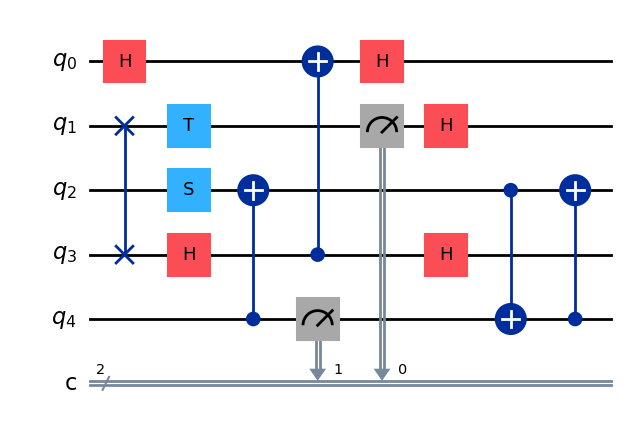

In [30]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(5,2)


qc.h(0)
qc.swap(3,1)
qc.h(3)
qc.cx(3,0)
qc.h([0,3])
qc.s([2])
qc.cx(4,2)
qc.measure(4,1)
qc.cx(2,4)
qc.cx(4,2)
qc.t(1)
qc.measure(1,0)
qc.h(1)
qc.draw('mpl')


Some quantitative measures allow comparing the quality of different circuits that perform the same task.

- **width**: is the total number of quantum and classical registers it needs.

The use of ancillas increases the width of a circuit, and therefore, reduces its quality compared to another circuit with less width.


In [31]:
print('anchura=', qc.width())

anchura= 7


- **size = cost**: the number of gates and measuring devices present in it the circuit

In [33]:
print('tamaño=',qc.size())


tamaño= 14


- **complexity**= is a measure of the *actual depth* associated with the number of *elementary gates* into which a circuit is decomposed.

 It is a number to be reduced. However, it is not an unambiguous measure as it depends on the library used. For example, if it is the NCT, then the cost of the [circuit](#Toffolidecomposition) is 1. However, if the library is taken by $ \{ H, S, T, \hbox{CNOT}\} $
then the cost rises to 7. Therefore, when comparing circuits, it is important to define them in the same basis.


complejidad= 16


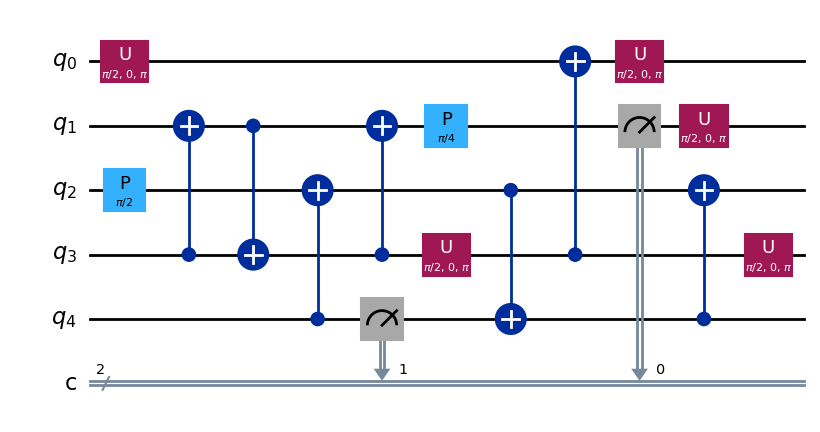

In [34]:
qc_dec=qc.decompose()
print('complejidad=', qc_dec.size())
qc_dec.draw('mpl')

- **depth**= to evaluate the *depth* it is necessary to group all the gates that can be performed in parallel into time slices of duration $\Delta$ (pulse).

  In particular, gates that act on different registers will not interfere and can be parallelized.
  For example, the [circuit that decomposes $U$](#CUdecomposition) has a cost equal to 6, but a depth equal to 5.

In [36]:
print('profundidad=', qc.depth())

profundidad= 5


- **unitary factors**= a circuit is a unitary operator that can be composed of $r$ factors $U = U_1 U_2...U_r$. In the circuit, each factor corresponds to a group of qubits that are disconnected from the others. This only affects the logic gates, not the measurement devices, which are always local.

In [37]:
print('factores unitarios =', qc.num_unitary_factors())

factores unitarios = 2


This result is not evident a priori, but if we permute qubits 2 and 3, the circuit clearly shows this factorization

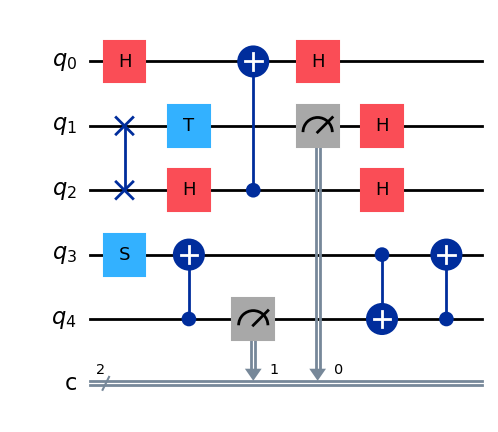

In [38]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(5,2)


qc.h(0)
qc.swap(2,1)
qc.h(2)
qc.cx(2,0)
qc.h([0,2])
qc.s([3])
qc.cx(4,3)
qc.measure(4,1)
qc.cx(3,4)
qc.cx(4,3)
qc.t(1)
qc.measure(1,0)
qc.h(1)
qc.draw('mpl')


## GHZ circuit

The following circuit creates the GHZ circuit. 


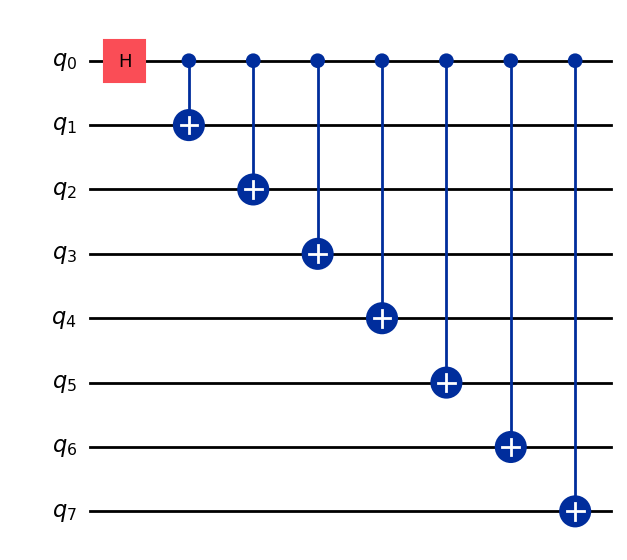

width= 8
depth= 8
unitary factors= 1


<IPython.core.display.Latex object>

In [73]:
qc = QuantumCircuit(n, name="BinaryTree_GHZ")
n = 8

# Layer 0: Hadamard
qc.h(0)

for i in range(1,n):
    qc.cx(0,i)

display(qc.draw(output='mpl'))
print('width=', qc.width())
print('depth=', qc.depth())
print('unitary factors=', qc.num_unitary_factors())

from qiskit.quantum_info import Statevector
Statevector.from_instruction(qc).draw('latex')

We see that the depth is equal to the widht. The transpiler does not seem to improve the situation

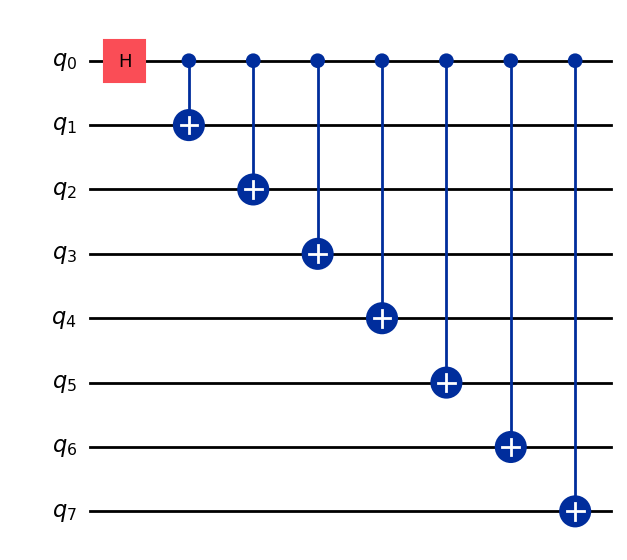

In [74]:
from qiskit.compiler import transpile
qct = transpile(qc)

display(qct.draw("mpl"))


A clever move of the controls allows to reduce the depth significantly. For example, let $n=16$. 

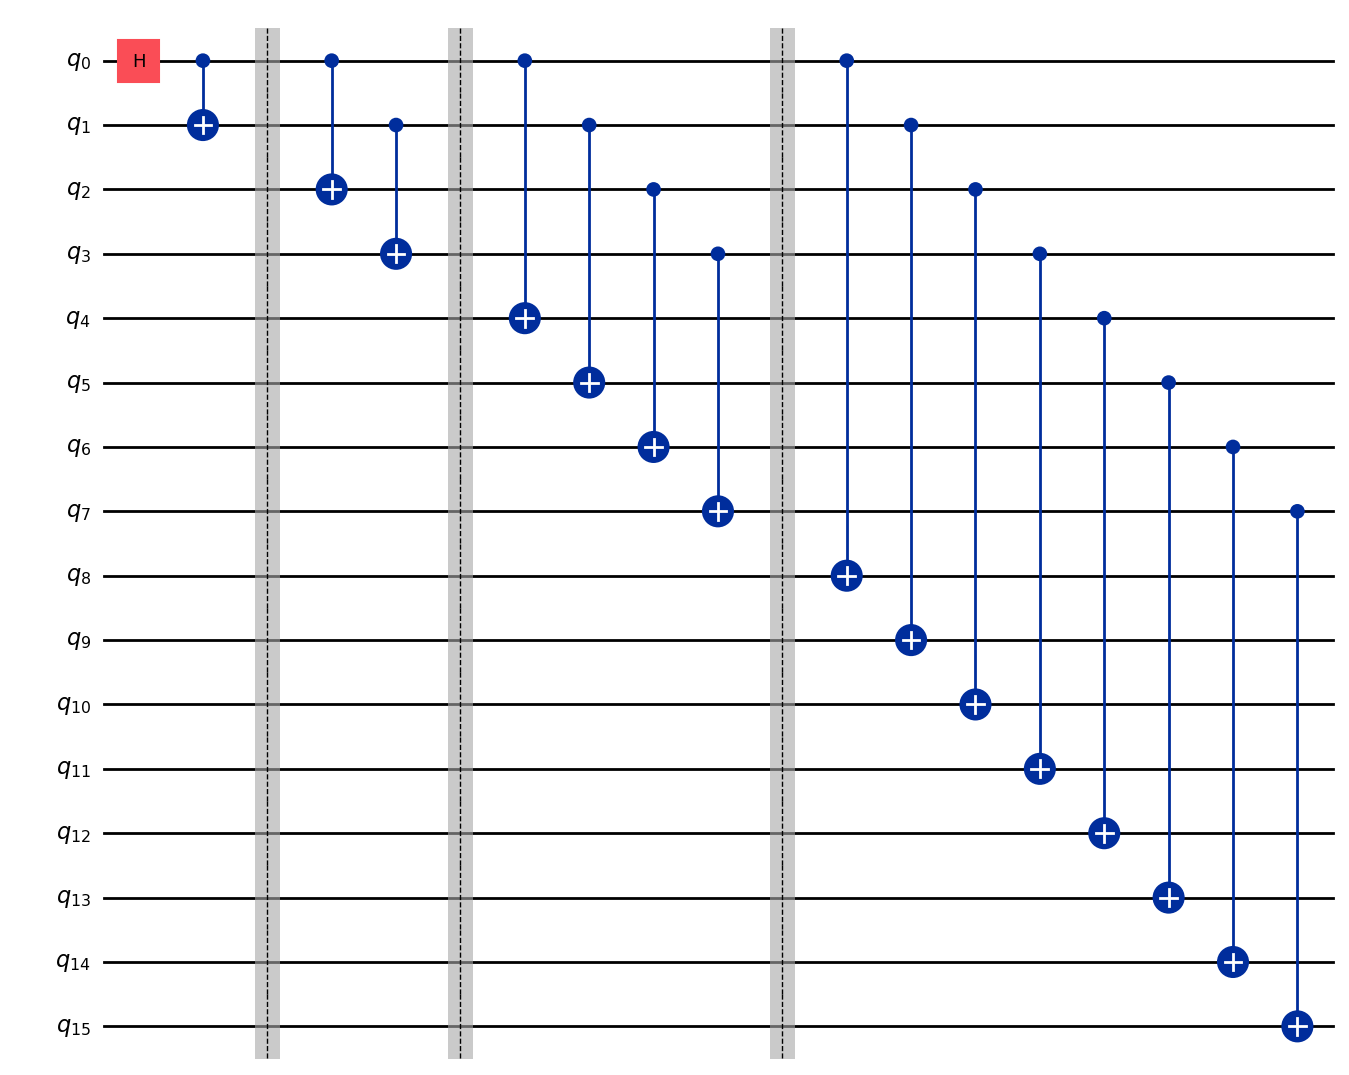

width= 16
depth= 5
unitary factors= 1


In [75]:
qc = QuantumCircuit(16, name="BinaryTree_GHZ")


# Layer 0: Hadamard
qc.h(0)

qc.cx(0, 1)
qc.barrier()

qc.cx(0, 2)
qc.cx(1, 3),qc.barrier()

qc.cx(0, 4),qc.cx(1, 5),qc.cx(2, 6),qc.cx(3, 7)
qc.barrier()

qc.cx(0, 8),qc.cx(1, 9),qc.cx(2, 10),qc.cx(3, 11),qc.cx(4, 12),qc.cx(5, 13),qc.cx(6, 14),qc.cx(7, 15)

# Draw circuit
display(qc.draw("mpl"))

print('width=', qc.width())
print('depth=', qc.depth())
print('unitary factors=', qc.num_unitary_factors())


    

<a id='complexity'></a>


# Computational Complexity
[<<<](#top)

An algorithm is a decomposition of a function into a composition of a set of *primitive functions*

When comparing computing strategies, it is necessary to analyze the relative cost of different algorithms. This is the task of computational complexity theory.

As a general rule, each *computational model* will reduce a complex problem to a series of elementary steps (*primitive operations*), to which we will assign a computational cost of 1.

The theory of *computational complexity* groups problems into classes where the use of computational resources (time or space) grows similarly.

<a id='classcomp'></a>

## Classical Complexity:
<br>

 -  **P** (*Polynomial*): we say that a problem belongs to this class if it can be solved in polynomial time ($t \sim $number of steps) in the size $n$ of the input data $t\sim \exists k \Rightarrow  {\cal O}(n^k)\, $. 

- **BPP** ("*Bounded probabilistic polynomial*"): problems that can be solved by a probabilistic Turing machine in polynomial time with an error probability $\leq 1/3$ for any input data.

- **NP** ("*Nondeterministic Polynomial*"): class of problems that can be *verified* in polynomial time, but lack an algorithm to be solved in polynomial time.

It is evident that **P**$\subseteq$ **NP**. It is not evident, although it is conjectured, that **P**$\neq$ **NP**, this being a central problem in mathematics.


-  **NPC** (*NP-Complete*): is a subset of **NPC**$\subset$**NP** that contains the hardest problems in this class. 
<br>
<br>
 A problem is **NPC** if any problem in **NP** can be reduced to it using a polynomial-time algorithm. 


The importance of this subclass is that the efficient resolution of just one of its elements implies the same for the entire class, or in other words, it would imply that **NP** = **P**.

Examples of this class are the *traveling salesman problem* and the *boolean satisfiability problem*.


- **PSPACE**. Class of problems that can be solved with a polynomial *memory* requirement in the size of the problem.

<div class="alert alert-block alert-warning">
<b> Examples:</b> 

- examples of the class <b>NP</b>: <i>integer factorization</i>, or the evaluation of <i>discrete logarithms</i>,... 
    
    
- examples of the class <b>NPC</b> are the <i>travelling salesman problem</i>, <i>graph coloring</i>, 
</div>


<a id='quantcomp'></a>

## Quantum Complexity:
<br>

We say that a circuit is *efficient* (*non-efficient*) if its *cost* scales in a *polynomial* (*exponential*) manner with the *width* of the circuit.

The decomposition of a generic unitary operator $U(n)$ will not be efficient, since it is specified by an exponential number $\sim 2^n\times 2^n$ of parameters.

Just as in classical computing, there are quantum complexity classes associated with families of problems that scale in the same way.


 - **BQP** (*Bounded Quantum Polynomial*): class of problems for which there exists a quantum algorithm with polynomial cost and an error probability $\leq 3$. It is the quantum analogue of the class **BPP**.


 - **quantum NP**: class of problems that admit a polynomial circuit in the number of qubits that *verifies* a potential solution with probability 1 if it is correct, and *rejects* any result that is not a solution with the same reliability.

- **QMA** (*Quantum Merlin-Arthur*): allowing an error probability $\leq 1/3$ in the **quantum NP** class, we obtain the quantum analogue of the **NP** class. There exists a **QMA**-complete class that contains the hardest problems in this category.

<div class="alert alert-block alert-warning">
<b> Examples:</b> 
    
- The most famous example of a <b>QMA</b>-complete problem is determining whether the ground state energy $E_0$ of a $k$-local Hamiltonian is $E_0\leq a$ or $E_0\geq a + 1/poly(n)$.
</div>


<div class="alert alert-block alert-danger">
<b> Note:</b> 
    

The theory of computational complexity attempts to establish inclusion relationships between these classes. 
Apart from the mentioned <b> P $\subseteq$ NP </b> it can be proven that

<p style="text-align:center;">   <b> P $\subseteq$ BPP $\subseteq$ BQP $\subseteq$ PSPACE </b>    </p>
    
</div>
